# Define proper Range efficiency level, when the event comes out

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from warnings import filterwarnings
filterwarnings('ignore')

In [3]:
# Main libraries
import pandas as pd
import numpy as np
import pytz
from scipy.stats import entropy

# Plots
import matplotlib.pyplot as plt

# Progress bar
from tqdm.auto import tqdm
tqdm.pandas()

pd.set_option('display.max_columns', None)

## Загрузка новостей

In [4]:
moscow_tz = pytz.timezone('Europe/Moscow')

In [5]:
PATH_TO_NEWS = r"../dataset/tradingview_economy_calendar/tw_calendar.csv"
news = pd.read_csv(PATH_TO_NEWS)
news = news[['date', 'currency', 'importance', 'title', 'indicator', 'country', 'category', 'actual', 'forecast', 'previous', 'comment', 'source', 'source_url', 'referenceDate', 'period', 'unit', 'scale']]
news.head()

,date,currency,importance,title,indicator,country,category,actual,forecast,previous,comment,source,source_url,referenceDate,period,unit,scale
0,2013-01-04T13:30:00.000Z,USD,1,Non Farm Payrolls,Non Farm Payrolls,US,lbr,NaN,NaN,NaN,Nonfarm payrolls is an employment report relea...,Bureau of Labour Statistics,http://www.bls.gov/,2012-12-31T00:00:00Z,DEC 2012,NaN,NaN
1,2013-01-04T13:30:00.000Z,USD,0,Unemployment Rate,Unemployment Rate,US,lbr,NaN,NaN,NaN,"In the United States, the unemployment rate me...",Bureau of Labour Statistics,http://www.bls.gov/,2012-12-31T00:00:00Z,DEC 2012,NaN,NaN
2,2013-01-06T13:00:00.000Z,EUR,-1,Inflation Rate MoM Flash,Inflation Rate Mom,DE,prce,NaN,NaN,0.2,"In Germany, the most important categories in t...",Federal Statistical Office,https://www.destatis.de,2013-12-31T00:00:00Z,Dec 2013,%,NaN
3,2013-01-17T09:30:00.000Z,GBP,-1,Retail Sales ex Fuel MoM,Retail Sales Ex Fuel,GB,cnsm,NaN,NaN,NaN,"In the United Kingdom, the Retail sales report...",Office for National Statistics,http://www.ons.gov.uk/,2013-12-31T00:00:00Z,Dec 2013,NaN,NaN
4,2013-01-17T09:30:00.000Z,GBP,-1,Retail Sales ex Fuel YoY,Retail Sales Ex Fuel,GB,cnsm,NaN,NaN,NaN,"In the United Kingdom, the Retail sales report...",Office for National Statistics,http://www.ons.gov.uk/,2013-12-31T00:00:00Z,Dec 2013,NaN,NaN


In [6]:
news = news[news['currency'] != 'CNY']

In [7]:
news.shape

(87671, 17)

### Построение агрегированных новостей для МЛ модели

In [8]:
news['utc_dt'] = pd.to_datetime(news['date'], utc=True).dt.tz_convert(moscow_tz)

In [9]:
def floor_or_ceil(x: str):
    """
    Если значения минут ближе к 30 или 00, значит округляем в большую сторону, иначе в меньшую.
    """
    x_dt = pd.to_datetime(x)
    if (29 >= x_dt.minute >= 20) or (59 >= x_dt.minute >= 50):  # TODO: May be change to last 5 minutes (20 -> 25 and 50 -> 55)
        return x_dt.ceil('30min', ambiguous='NaT', nonexistent='shift_forward')
    else:
        return x_dt.floor('30min')

In [10]:
news['custom_event_time'] = news['utc_dt'].progress_apply(floor_or_ceil)

  0%|          | 0/87671 [00:00<?, ?it/s]

In [11]:
news['importance'] = news['importance'] + 1

In [12]:
def build_hour_features(
    news_df: pd.DataFrame,
    event_time_column: str = 'custom_event_time'
) -> pd.DataFrame:
    """
    Build hour-level aggregated features from event-level news dataframe.

    Parameters
    ----------
    news_df : pd.DataFrame
        Event-level news data. Must contain:
        ['event_hour', 'event_type', 'news_class',
         'impact_rank', 'is_key_event', 'event_weight']

    key_event_types : list[str], optional
        List of key event types to build presence flags for
        (e.g. ['NFP', 'CPI', 'PMI_MANUFACTURING']).
        If None, inferred from is_key_event == True.

    Returns
    -------
    pd.DataFrame
        Hour-level feature table indexed by event_hour.
    """

    df = news_df.copy()

    # -----------------------------
    # 1. BASIC COUNTS & INTENSITY
    # -----------------------------
    agg = df.groupby(event_time_column).agg(
        base_news_count=("importance", "count"),
        base_high_impact_count=("importance", lambda x: (x == 2).sum()),
        base_sum_impact_rank=("importance", "sum"),
        base_max_impact_rank=("importance", "max"),
    )

    return agg

In [13]:
news_agg = build_hour_features(news)

In [14]:
news_agg['is_high_event'] = (news_agg['base_high_impact_count'] > 0).astype(int)

In [15]:
news_agg

,base_news_count,base_high_impact_count,base_sum_impact_rank,base_max_impact_rank,is_high_event
custom_event_time,,,,,
2013-01-04 17:30:00+04:00,2,1,3,2,1
2013-01-06 17:00:00+04:00,1,0,0,0,0
2013-01-17 13:30:00+04:00,5,0,0,0,0
2013-01-23 13:30:00+04:00,23,0,19,1,0
2013-01-25 17:30:00+04:00,1,0,1,1,0
...,...,...,...,...,...
2025-12-31 16:30:00+03:00,3,0,1,1,0
2025-12-31 18:00:00+03:00,2,0,0,0,0
2025-12-31 18:30:00+03:00,9,0,2,1,0


# Prices

In [16]:
import os

In [17]:
files = os.listdir("../dataset/historical_prices")
print(files)

['AUDCAD_M30.csv', 'AUDUSD_M30.csv', 'BRENTUSD_M30.csv', 'EURAUD_M30.csv', 'EURCAD_M30.csv', 'EURGBP_M30.csv', 'EURUSD_M30.csv', 'GBPCHF_M30.csv', 'GBPUSD_M30.csv', 'NZDUSD_M30.csv', 'USDCAD_M30.csv', 'USDCHF_M30.csv', 'USDJPY_M30.csv', 'XAGUSD_M30.csv', 'XAUUSD_M30.csv']


In [18]:
pairs = [p.split('_')[0] for p in files]
print(pairs)

['AUDCAD', 'AUDUSD', 'BRENTUSD', 'EURAUD', 'EURCAD', 'EURGBP', 'EURUSD', 'GBPCHF', 'GBPUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDJPY', 'XAGUSD', 'XAUUSD']


In [19]:
def read_pair(pair: str, path2folder: str = "../dataset/historical_prices/"):
    return pd.read_csv(f'{path2folder}/{pair}_M30.csv',
                        sep="\t",
                        names=["time", "open", "high", "low", "close", "volume", "spread"],
                        header=0,
                        parse_dates=["time"])

# Price featuring

In [20]:
from price_featuring import calculate_chaos_features, label_future_chaos

In [21]:
def add_features_and_targets_to_prices(prices: pd.DataFrame, period: int, N: int = 8):
    prices = calculate_chaos_features(prices, period)
    prices = label_future_chaos(prices, N=N)
    return prices

In [22]:
def get_base_and_quote_currency(pair: str):
    return pair[:-3], pair[-3:]

In [93]:
PERIOD = 24

In [94]:
prices = []
for pair in tqdm(pairs):
    pair_prices = read_pair(pair)
    pair_prices['instrument'] = pair
    pair_prices[['base_currency', 'quote_currency']] = get_base_and_quote_currency(pair)
    pair_prices = add_features_and_targets_to_prices(pair_prices, period=PERIOD, N=8)
    prices.append(pair_prices)

prices = pd.concat(prices)

  0%|          | 0/15 [00:00<?, ?it/s]

## Plot indicators

In [97]:
import mplfinance as mpf

In [95]:
pr = prices[prices['instrument'] == 'EURUSD'].set_index('time').iloc[500:700, :]
pr = pr[['open', 'high', 'low', 'close', 'kaufman_efficiency_ratio', 'kaufman_efficiency_ratio_future']]

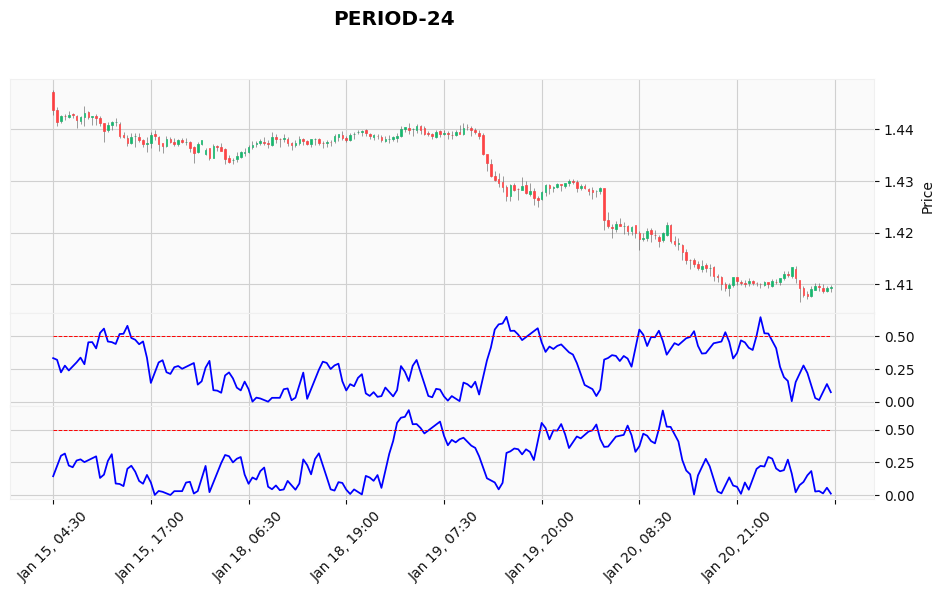

In [101]:
apds = [
    mpf.make_addplot(pr['kaufman_efficiency_ratio'], panel=1, color='blue'),
    mpf.make_addplot(pr['kaufman_efficiency_ratio_future'], panel=2, color='blue'),
    mpf.make_addplot([0.5]*len(pr), panel=1, color='red', secondary_y=False, width=0.7, linestyle='dashed'),
    mpf.make_addplot([0.5]*len(pr), panel=2, color='red', secondary_y=False, width=0.7, linestyle='dashed')
]

mpf.plot(pr, type='candle', style='yahoo', title=f'PERIOD-{PERIOD}', addplot=apds, volume=False, figsize=(12, 6))

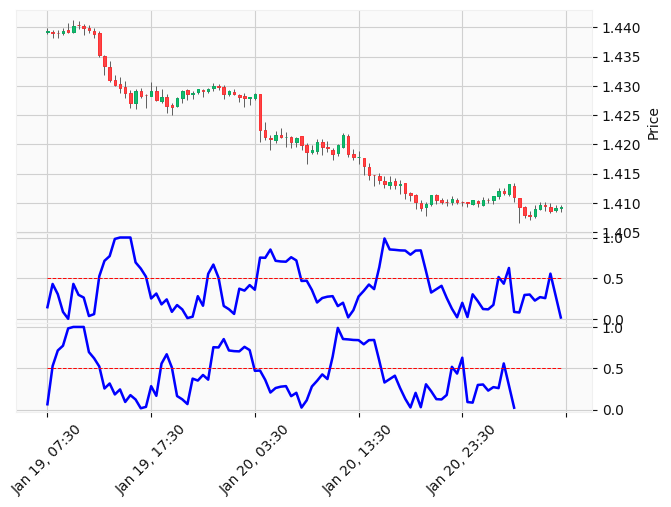

In [79]:
apds = [
    mpf.make_addplot(pr['kaufman_efficiency_ratio'], panel=1, color='blue'),
    mpf.make_addplot(pr['kaufman_efficiency_ratio_future'], panel=2, color='blue'),
    mpf.make_addplot([0.5]*len(pr), panel=1, color='red', secondary_y=False, width=0.7, linestyle='dashed'),
    mpf.make_addplot([0.5]*len(pr), panel=2, color='red', secondary_y=False, width=0.7, linestyle='dashed')
]

mpf.plot(pr, type='candle', style='yahoo', addplot=apds, volume=False)

<Axes: >

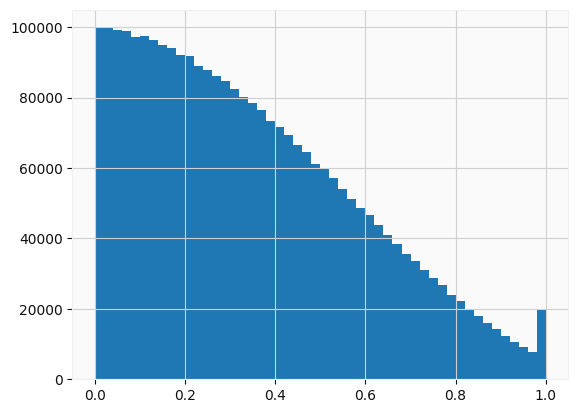

In [69]:
prices['kaufman_efficiency_ratio'].hist(bins=50)

<Axes: >

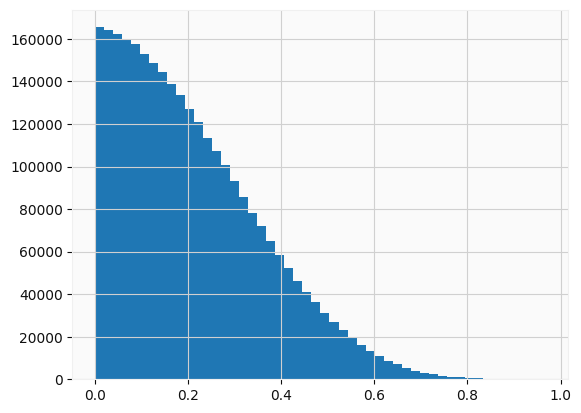

In [99]:
prices['kaufman_efficiency_ratio'].hist(bins=50)

In [100]:
prices['utc_dt'] = pd.to_datetime(prices['time']).dt.tz_localize(moscow_tz)

In [101]:
df = pd.merge(prices, news_agg, how='left', left_on='utc_dt', right_on='custom_event_time')

In [102]:
news_agg.index.min()

Timestamp('2013-01-04 17:30:00+0400', tz='Europe/Moscow')

In [103]:
# Crop dataframe, where we have event data
df = df[df['utc_dt'] > '2013-01-04']

In [104]:
def add_time_features(data: pd.DataFrame, dt_col: str):
    data[dt_col] = pd.to_datetime(data[dt_col])
    data['week'] = data[dt_col].dt.isocalendar().week
    data['dayofweek'] = data[dt_col].dt.dayofweek
    data['day'] = data[dt_col].dt.day
    data['hour'] = data[dt_col].dt.hour
    return data

In [105]:
df = add_time_features(df, 'utc_dt')

In [106]:
df.head()

,time,open,high,low,close,volume,spread,instrument,base_currency,quote_currency,range,kaufman_efficiency_ratio,custom_range_efficiency,wick_ratio,relative_range,relative_atr,relative_volume,normalized_bb_width,price_volume_ratio,date,daily_atr,target_is_volatile,target_volatility_category,target_range_normalized,target_is_chaos,custom_range_efficiency_future,kaufman_efficiency_ratio_future,utc_dt,base_news_count,base_high_impact_count,base_sum_impact_rank,base_max_impact_rank,is_high_event,week,dayofweek,day,hour
37571,2013-01-04 00:30:00,1.03366,1.03415,1.03335,1.03371,1218,28,AUDCAD,AUD,CAD,0.00080,0.938567,0.460087,0.062500,-0.120197,0.416140,-0.656404,6.371239,6.568144e-07,2013-01-04,0.004939,0,0,0.366508,0,0.272358,0.381381,2013-01-04 00:30:00+04:00,NaN,NaN,NaN,NaN,NaN,1,4,4,0
37572,2013-01-04 01:00:00,1.03362,1.03451,1.03319,1.03406,631,63,AUDCAD,AUD,CAD,0.00132,0.713355,0.389809,0.333333,1.326987,0.996010,-1.230664,4.406828,2.091918e-06,2013-01-04,0.004939,0,0,0.407006,0,0.348675,0.404624,2013-01-04 01:00:00+04:00,NaN,NaN,NaN,NaN,NaN,1,4,4,1
37573,2013-01-04 01:30:00,1.03404,1.03432,1.03324,1.03377,1295,51,AUDCAD,AUD,CAD,0.00108,0.715210,0.327888,0.250000,0.619544,1.149492,-0.553688,1.690974,8.339768e-07,2013-01-04,0.004939,1,0,0.506226,1,0.403896,0.640884,2013-01-04 01:30:00+04:00,NaN,NaN,NaN,NaN,NaN,1,4,4,1
37574,2013-01-04 02:00:00,1.03379,1.03443,1.03360,1.03415,1044,44,AUDCAD,AUD,CAD,0.00083,0.154639,0.193103,0.433734,-0.081853,0.955523,-0.787873,1.428150,7.950192e-07,2013-01-04,0.004939,1,0,0.629745,1,0.367013,0.324895,2013-01-04 02:00:00+04:00,NaN,NaN,NaN,NaN,NaN,1,4,4,2
37575,2013-01-04 02:30:00,1.03409,1.03422,1.03274,1.03275,1268,31,AUDCAD,AUD,CAD,0.00148,0.465798,0.231539,0.905405,1.645547,1.575283,-0.572145,2.712378,1.167192e-06,2013-01-04,0.004939,1,0,0.500151,1,0.387147,0.550847,2013-01-04 02:30:00+04:00,NaN,NaN,NaN,NaN,NaN,1,4,4,2


# Check what Range efficiency level should use

In [73]:
import seaborn as sns
sns.set_style("whitegrid")

<Axes: xlabel='custom_range_efficiency', ylabel='Probability'>

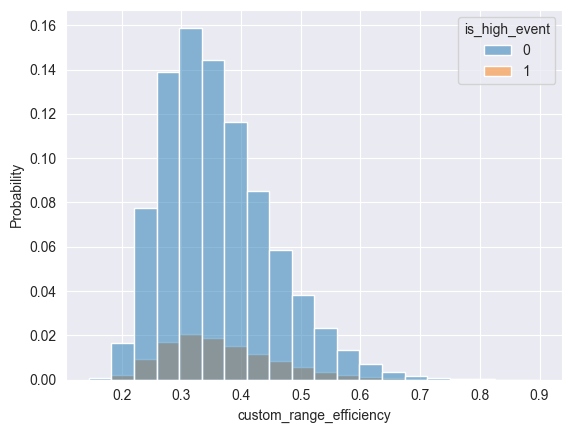

In [172]:
sns.histplot(data=df, x='custom_range_efficiency', hue='is_high_event', stat='probability', bins=20)

In [107]:
df['is_news'] = df['is_high_event'].fillna(-1) + 1

In [108]:
df['is_news'].value_counts()

is_news
0.0    1845072
1.0     477476
2.0      62989
Name: count, dtype: int64

In [109]:
df.head()

,time,open,high,low,close,volume,spread,instrument,base_currency,quote_currency,range,kaufman_efficiency_ratio,custom_range_efficiency,wick_ratio,relative_range,relative_atr,relative_volume,normalized_bb_width,price_volume_ratio,date,daily_atr,target_is_volatile,target_volatility_category,target_range_normalized,target_is_chaos,custom_range_efficiency_future,kaufman_efficiency_ratio_future,utc_dt,base_news_count,base_high_impact_count,base_sum_impact_rank,base_max_impact_rank,is_high_event,week,dayofweek,day,hour,is_news
37571,2013-01-04 00:30:00,1.03366,1.03415,1.03335,1.03371,1218,28,AUDCAD,AUD,CAD,0.00080,0.938567,0.460087,0.062500,-0.120197,0.416140,-0.656404,6.371239,6.568144e-07,2013-01-04,0.004939,0,0,0.366508,0,0.272358,0.381381,2013-01-04 00:30:00+04:00,NaN,NaN,NaN,NaN,NaN,1,4,4,0,0.0
37572,2013-01-04 01:00:00,1.03362,1.03451,1.03319,1.03406,631,63,AUDCAD,AUD,CAD,0.00132,0.713355,0.389809,0.333333,1.326987,0.996010,-1.230664,4.406828,2.091918e-06,2013-01-04,0.004939,0,0,0.407006,0,0.348675,0.404624,2013-01-04 01:00:00+04:00,NaN,NaN,NaN,NaN,NaN,1,4,4,1,0.0
37573,2013-01-04 01:30:00,1.03404,1.03432,1.03324,1.03377,1295,51,AUDCAD,AUD,CAD,0.00108,0.715210,0.327888,0.250000,0.619544,1.149492,-0.553688,1.690974,8.339768e-07,2013-01-04,0.004939,1,0,0.506226,1,0.403896,0.640884,2013-01-04 01:30:00+04:00,NaN,NaN,NaN,NaN,NaN,1,4,4,1,0.0
37574,2013-01-04 02:00:00,1.03379,1.03443,1.03360,1.03415,1044,44,AUDCAD,AUD,CAD,0.00083,0.154639,0.193103,0.433734,-0.081853,0.955523,-0.787873,1.428150,7.950192e-07,2013-01-04,0.004939,1,0,0.629745,1,0.367013,0.324895,2013-01-04 02:00:00+04:00,NaN,NaN,NaN,NaN,NaN,1,4,4,2,0.0
37575,2013-01-04 02:30:00,1.03409,1.03422,1.03274,1.03275,1268,31,AUDCAD,AUD,CAD,0.00148,0.465798,0.231539,0.905405,1.645547,1.575283,-0.572145,2.712378,1.167192e-06,2013-01-04,0.004939,1,0,0.500151,1,0.387147,0.550847,2013-01-04 02:30:00+04:00,NaN,NaN,NaN,NaN,NaN,1,4,4,2,0.0


<Axes: xlabel='custom_range_efficiency_future', ylabel='Probability'>

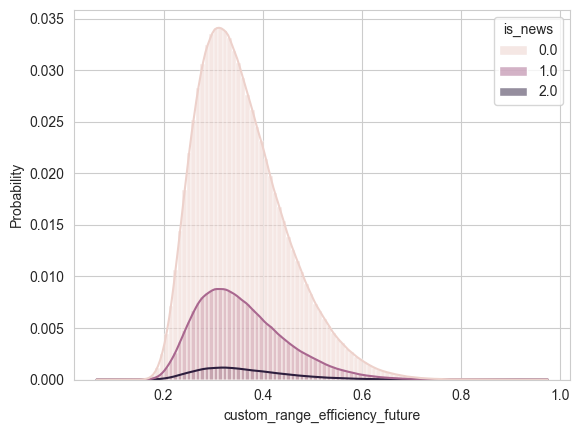

In [93]:
sns.histplot(data=df, x='custom_range_efficiency_future', hue='is_news', stat='probability', bins=100, kde=True)

<Axes: xlabel='kaufman_efficiency_ratio_future', ylabel='Probability'>

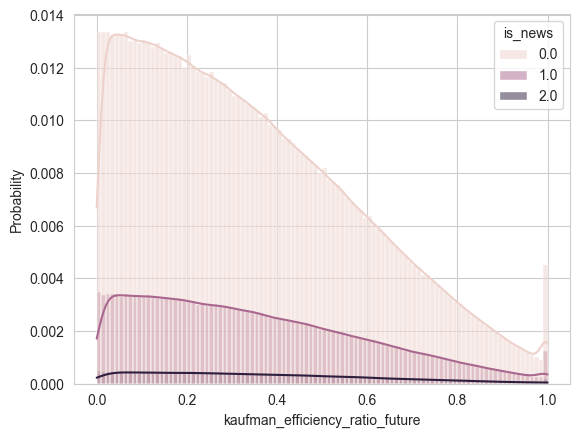

In [110]:
sns.histplot(data=df, x='kaufman_efficiency_ratio_future', hue='is_news', stat='probability', bins=100, kde=True)

count    540461.000000
mean          0.360978
std           0.090572
min           0.145078
25%           0.293608
50%           0.347002
75%           0.414409
max           0.900551
Name: custom_range_efficiency, dtype: float64

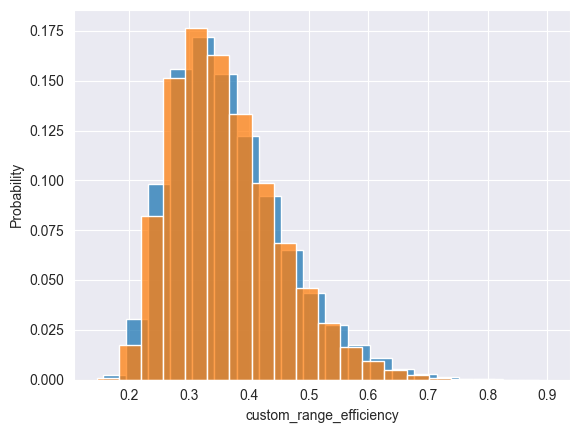

In [89]:
sns.histplot(df.query('base_high_impact_count >= 1')['custom_range_efficiency'], bins=20, stat='probability')
sns.histplot(df.query('base_high_impact_count < 1')['custom_range_efficiency'], bins=20, stat='probability')
df['custom_range_efficiency'].describe()

count    540461.000000
mean          0.360978
std           0.090572
min           0.145078
25%           0.293608
50%           0.347002
75%           0.414409
max           0.900551
Name: custom_range_efficiency, dtype: float64

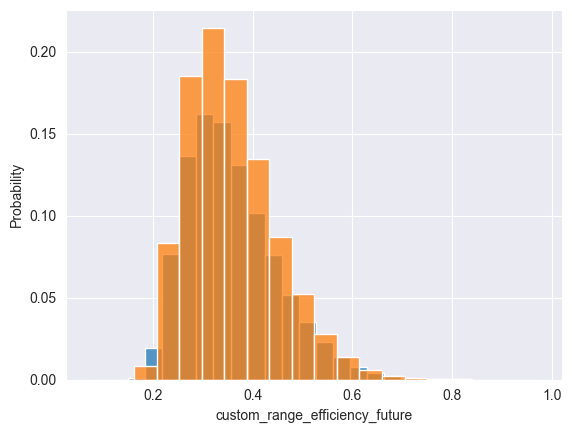

In [153]:
sns.histplot(df.query('base_high_impact_count >= 1')['custom_range_efficiency_future'], bins=20, stat='probability')
sns.histplot(df.query('base_high_impact_count < 1')['custom_range_efficiency_future'], bins=20, stat='probability')
df['custom_range_efficiency'].describe()

In [ ]:
noise_range_efficiency_level = 0.222222
trend_range_efficiency_level = 0.320027

<Axes: xlabel='kaufman_efficiency_ratio', ylabel='Probability'>

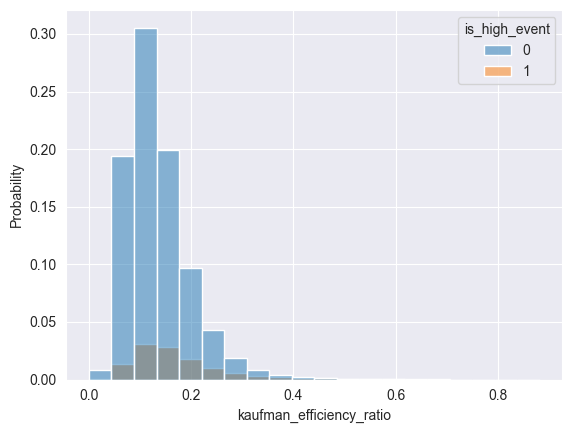

In [174]:
sns.histplot(data=df, x='kaufman_efficiency_ratio', hue='is_high_event', stat='probability', bins=20)

<Axes: xlabel='kaufman_efficiency_ratio_future', ylabel='Probability'>

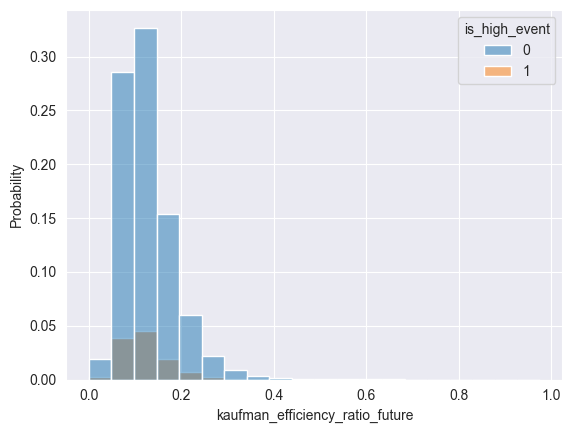

In [175]:
sns.histplot(data=df, x='kaufman_efficiency_ratio_future', hue='is_high_event', stat='probability', bins=20)

<Axes: xlabel='kaufman_efficiency_ratio', ylabel='Probability'>

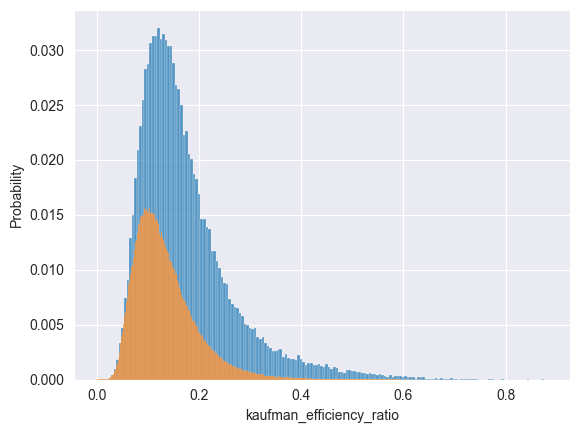

In [159]:
sns.histplot(df.query('base_high_impact_count >= 1')['kaufman_efficiency_ratio'], stat='probability')
sns.histplot(df.query('base_high_impact_count < 1')['kaufman_efficiency_ratio'], stat='probability')

<Axes: xlabel='kaufman_efficiency_ratio_future', ylabel='Probability'>

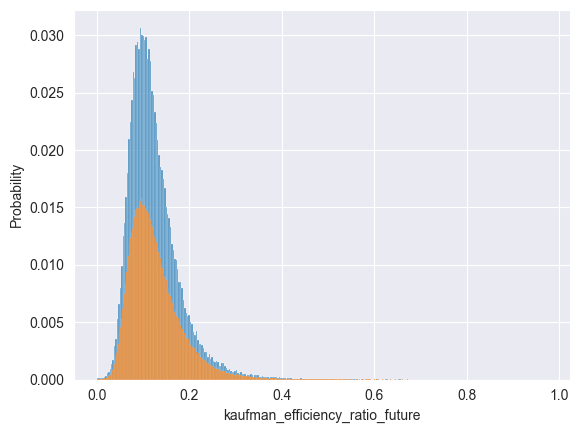

In [157]:
sns.histplot(df.query('base_high_impact_count >= 1')['kaufman_efficiency_ratio_future'], stat='probability')
sns.histplot(df.query('base_high_impact_count < 1')['kaufman_efficiency_ratio_future'], stat='probability')

In [92]:
df.query('base_high_impact_count >= 1')['kaufman_efficiency_ratio'].describe()

count    62989.000000
mean         0.174612
std          0.093892
min          0.008475
25%          0.111111
50%          0.151473
75%          0.210843
max          0.875758
Name: kaufman_efficiency_ratio, dtype: float64

In [93]:
df.query('base_high_impact_count < 1')['kaufman_efficiency_ratio'].describe()

count    477472.000000
mean          0.134544
std           0.063113
min           0.000000
25%           0.090759
50%           0.121642
75%           0.163510
max           0.881860
Name: kaufman_efficiency_ratio, dtype: float64

In [94]:
noise_kf_range_efficiency_level = 0.210843
trend_kf_range_efficiency_level = 0.111111

<Axes: xlabel='wick_ratio', ylabel='Probability'>

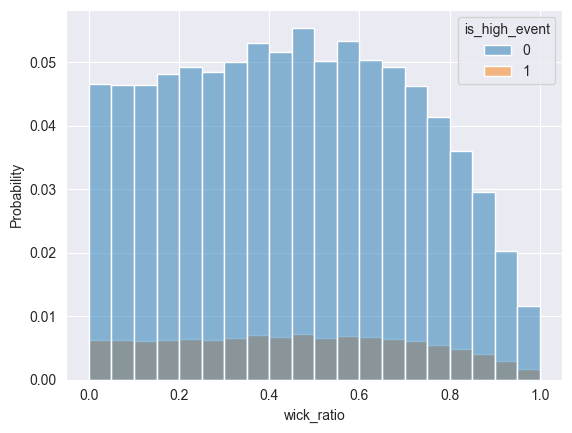

In [176]:
sns.histplot(data=df, x='wick_ratio', hue='is_high_event', stat='probability', bins=20)

<Axes: xlabel='wick_ratio', ylabel='Probability'>

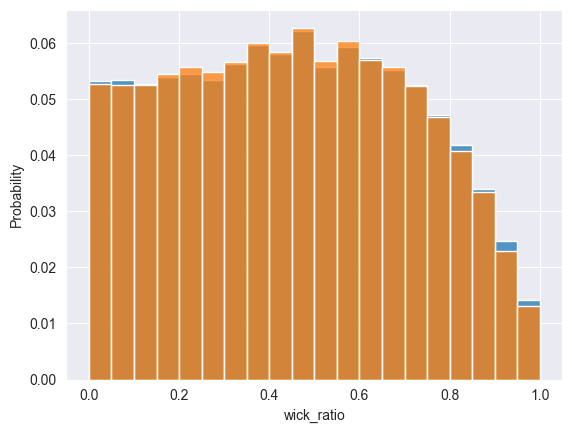

In [155]:
sns.histplot(df.query('base_high_impact_count >= 1')['wick_ratio'], bins=20, stat='probability')
sns.histplot(df.query('base_high_impact_count < 1')['wick_ratio'], bins=20, stat='probability')

In [156]:
df.query('base_high_impact_count >= 1')['wick_ratio'].describe()

count    62989.000000
mean         0.456004
std          0.262340
min          0.000000
25%          0.234042
50%          0.453888
75%          0.666667
max          1.000000
Name: wick_ratio, dtype: float64

## Calculate last min/mean/max for N previous values of future_ranges (target_range_normalized)

In [59]:
df = df.sort_values(['extra_dominant_event_type', 'instrument', 'utc_dt']).reset_index(drop=True)

df['prev_5_mean_range_norm'] = (
    df.groupby(['extra_dominant_event_type', 'instrument'])['target_range_normalized']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)

df['prev_5_min_range_norm'] = (
    df.groupby(['extra_dominant_event_type', 'instrument'])['target_range_normalized']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).min())
)

df['prev_5_max_range_norm'] = (
    df.groupby(['extra_dominant_event_type', 'instrument'])['target_range_normalized']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).max())
)

In [60]:
df['prev_this_event_range_norm'] = (
    df.groupby(['extra_dominant_event_type', 'instrument'])['target_range_normalized']
    .transform(lambda x: x.shift(1))
)

In [61]:
df.tail()

,custom_event_time,base_news_count,base_high_impact_count,base_sum_impact_rank,base_max_impact_rank,extra_dominant_event_type,event_entropy,e_CORE_CPI,e_CPI,e_FOMC_PRES_CONF,e_GDP,e_NFP,e_PCE,e_PMI_MANUFACTURING,e_PMI_SERVICES,e_RETAIL_SALES,cat_BONDS,cat_CB_SPEECH,cat_COMMODITIES,cat_CONSUMER_HOUSING,cat_ECONOMIC_ACTIVITY,cat_GDP,cat_INFLATION,cat_LABOR_MARKET,cat_MANUFACTORING,cat_MONETARY_POLICY,cat_SENTIMENT,cat_TRADE_FINANCE,cur_AUD,cur_EUR,cur_GBP,cur_JPY,cur_USD,extra_last_key_event_name,extra_last_key_event_hours_ago,extra_last_max_impact_hours_ago,time,open,high,low,close,volume,spread,instrument,base_currency,quote_currency,range,kaufman_efficiency_ratio,custom_range_efficiency,wick_ratio,relative_range,relative_atr,relative_volume,normalized_bb_width,price_volume_ratio,date,daily_atr,target_is_volatile,target_volatility_category,target_range_normalized,target_is_chaos,utc_dt,week,dayofweek,day,hour,prev_5_mean_range_norm,prev_5_min_range_norm,prev_5_max_range_norm,prev_this_event_range_norm
540460,2025-10-06 12:00:00+03:00,2,0,1,1,RETAIL_SALES,0.000000,0,0,0,0,0,0,0,0,2,0,0,0,2,0,0,0,0,0,0,0,0,0,2,0,0,0,CPI,96.5,67.0,2025-10-06 12:00:00,3942.235,3944.705,3938.768,3943.475,30,629,XAUUSD,XAU,USD,5.937,0.010091,0.246558,3.787903,-0.530854,1.110593,0.000000,4.710205,0.197900,2025-10-06,53.521985,0,0,0.373491,0,2025-10-06 12:00:00+03:00,41,0,6,12,0.375169,0.217076,0.533866,0.352037
540461,2025-10-14 02:00:00+03:00,1,0,1,1,RETAIL_SALES,0.000000,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,CPI,278.5,81.0,2025-10-14 02:00:00,4114.275,4116.685,4112.655,4114.798,30,974,XAUUSD,XAU,USD,4.030,0.001136,0.200173,6.705545,-1.268221,-1.666277,0.000000,2.556590,0.134333,2025-10-14,65.999276,1,0,0.674856,1,2025-10-14 02:00:00+03:00,42,1,14,2,0.401381,0.217076,0.533866,0.373491
540462,2025-10-24 09:00:00+03:00,4,1,3,2,RETAIL_SALES,0.000000,0,0,0,0,0,0,0,0,4,0,0,0,4,0,0,0,0,0,0,0,0,0,0,4,0,0,GDP,188.0,6.5,2025-10-24 09:00:00,4104.048,4104.498,4081.048,4089.265,30,737,XAUUSD,XAU,USD,23.450,0.076953,0.328452,0.586282,1.373206,-1.086637,0.000000,5.273580,0.781667,2025-10-24,105.042927,0,0,0.473359,0,2025-10-24 09:00:00+03:00,43,4,24,9,0.492937,0.352037,0.674856,0.674856
540463,2025-11-21 10:00:00+03:00,5,1,3,2,RETAIL_SALES,0.500402,0,0,0,0,0,0,0,0,4,0,0,0,4,0,0,0,0,0,1,0,0,0,0,5,0,0,GDP,103.0,7.0,2025-11-21 10:00:00,4032.329,4037.435,4024.538,4037.305,30,751,XAUUSD,XAU,USD,12.897,0.025147,0.285376,1.591841,-0.259535,-0.382998,0.000000,5.404179,0.429900,2025-11-21,95.612146,0,0,0.429548,0,2025-11-21 10:00:00+03:00,47,4,21,10,0.481522,0.352037,0.674856,0.473359
540464,2025-12-09 03:00:00+03:00,1,0,1,1,RETAIL_SALES,0.000000,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,GDP,24.0,81.0,2025-12-09 03:00:00,4194.435,4195.515,4191.125,4192.065,30,665,XAUUSD,XAU,USD,4.390,0.030640,0.168955,0.852321,-0.719473,-1.147955,0.162306,2.061271,0.146333,2025-12-09,72.974391,0,0,0.175171,0,2025-12-09 03:00:00+03:00,50,1,9,3,0.460658,0.352037,0.674856,0.429548


In [62]:
df['target_is_chaos'].value_counts(normalize=True)

target_is_chaos
0    0.738956
1    0.261044
Name: proportion, dtype: float64